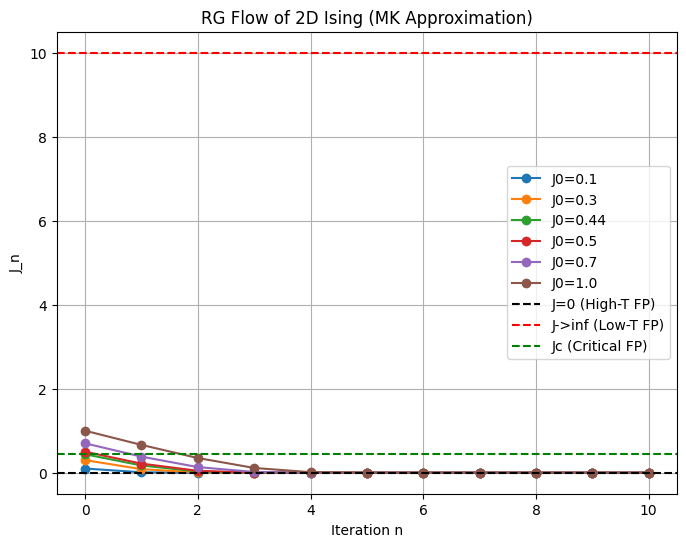

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# RG 映射函数
def R(J):
    return np.arctanh(np.tanh(J)**2)

# 初始耦合集合
J0_list = [0.1, 0.3, 0.44, 0.5, 0.7, 1.0]

# 迭代次数
n_iter = 10

plt.figure(figsize=(8,6))

for J0 in J0_list:
    Js = [J0]
    for n in range(n_iter):
        J_new = R(Js[-1])
        Js.append(J_new)
    plt.plot(range(n_iter+1), Js, marker='o', label=f'J0={J0}')

plt.axhline(0, color='black', linestyle='--', label='J=0 (High-T FP)')
plt.axhline(10, color='red', linestyle='--', label='J->inf (Low-T FP)')
plt.axhline(0.4407, color='green', linestyle='--', label='Jc (Critical FP)')

plt.xlabel('Iteration n')
plt.ylabel('J_n')
plt.title('RG Flow of 2D Ising (MK Approximation)')
plt.legend()
plt.grid(True)
plt.show()


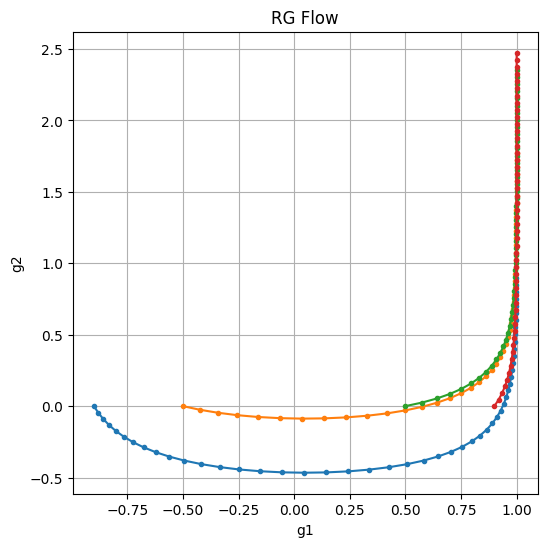

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 示例：自定义 RG 更新函数
def RG_step(g):
    g1, g2 = g
    # 简单示例：类似 Ising 的流
    g1_new = g1 + 0.1 * (1 - g1**2)
    g2_new = g2 + 0.05 * g1
    return np.array([g1_new, g2_new])

# 初始点
initial_points = [[-0.9, 0], [-0.5, 0], [0.5, 0], [0.9, 0]]

plt.figure(figsize=(6,6))
for g0 in initial_points:
    g = np.array(g0)
    trajectory = [g.copy()]
    for _ in range(50):
        g = RG_step(g)
        trajectory.append(g.copy())
    trajectory = np.array(trajectory)
    plt.plot(trajectory[:,0], trajectory[:,1], '-o', markersize=3)

plt.xlabel('g1')
plt.ylabel('g2')
plt.title('RG Flow')
plt.grid(True)
plt.show()
